# Task 1
You are working for a car dealership company aiming to enhance its pricing strategy.

The company has collected a vast dataset containing various attributes of cars, including features such as mileage, horsepower, number of doors, brand, model year, and more. Your task is to develop a robust machine learning model to predict car prices accurately based on these features.
Download the dataset
- Perform necessary EDA and Data Wrangling
- Implement Linear Regression
- Evaluate LR using different metrics
- Plot training and testing results

In [14]:
#@title 📦 Kaggle Competition Loader { display-mode: "form" }
#@markdown ---
#@markdown ### How to use
#@markdown 1. In Colab, add **two** secrets via the 🔑 Secrets panel (left sidebar):
#@markdown    - `KAGGLE_USERNAME` → your Kaggle username
#@markdown    - `KAGGLE_KEY` → your Kaggle API key
#@markdown    Toggle "Notebook access" on for both.
#@markdown 2. Run this cell (code stays hidden — double-click the title to peek).
#@markdown 3. When prompted, paste the **full Kaggle competition URL**
#@markdown    (e.g. `https://www.kaggle.com/c/titanic`) — or just the slug.
#@markdown 4. After it finishes, your data is available as:
#@markdown    - `data['train.csv']`, `data['test.csv']`, etc. → pandas DataFrames
#@markdown    - `data['some_file.ext']` → file path (non-CSV files)
#@markdown    - `data_dir` → the local folder containing everything
#@markdown ---

import os
import re
import shutil
import kagglehub
import pandas as pd


def _authenticate_kaggle():
    """
    Pulls Kaggle credentials from Colab secrets and sets them as env vars,
    so kagglehub picks them up silently instead of falling back to
    kagglehub.login()'s interactive OAuth flow (which is what was hanging
    the automated run).
    """
    try:
        from google.colab import userdata
    except ImportError:
        # Not running in Colab — assume env vars/kaggle.json are already set up.
        return

    missing = []
    for env_name in ("KAGGLE_USERNAME", "KAGGLE_KEY"):
        if os.environ.get(env_name):
            continue  # already set
        try:
            value = userdata.get(env_name)
        except Exception:
            value = None
        if value:
            os.environ[env_name] = value
        else:
            missing.append(env_name)

    if missing:
        raise RuntimeError(
            "Missing Kaggle credential(s) in Colab secrets: "
            f"{', '.join(missing)}.\n"
            "Add them via the 🔑 Secrets panel in the left sidebar "
            "(toggle 'Notebook access' on for each), then re-run this cell."
        )


def _parse_kaggle_ref(text: str):
    """
    Determines whether the input points to a Kaggle *dataset* or
    *competition*, and extracts the identifier kagglehub needs.

    Returns:
        (kind, ref) where kind is 'dataset' or 'competition', and ref is
        either "owner/dataset-slug" (datasets) or "comp-slug" (competitions).
    """
    text = text.strip().rstrip('/')

    # Full dataset URL: kaggle.com/datasets/<owner>/<slug>
    match = re.search(r'kaggle\.com/datasets/([^/?#]+)/([^/?#]+)', text)
    if match:
        return 'dataset', f"{match.group(1)}/{match.group(2)}"

    # Full competition URL: kaggle.com/c/<slug> or kaggle.com/competitions/<slug>
    match = re.search(r'kaggle\.com/(?:c|competitions)/([^/?#]+)', text)
    if match:
        return 'competition', match.group(1)

    # Any other kaggle.com URL shape — can't reliably classify it
    if "kaggle.com" in text:
        return None, text.split('/')[-1]

    # Bare input, no domain: "owner/slug" implies a dataset handle;
    # a single token is treated as a competition slug.
    if '/' in text:
        return 'dataset', text
    return 'competition', text


def fetch_kaggle_competition(comp_url: str = None, copy_to_local: bool = True):
    """
    Downloads a Kaggle dataset or competition via kagglehub and loads all CSVs.

    Args:
        comp_url: Full Kaggle dataset/competition URL, or a slug
            ("comp-slug" for a competition, "owner/dataset-slug" for a
            dataset). If None, you'll be prompted.
        copy_to_local: If True, copies files out of the kagglehub cache into
            a local folder named after the slug.

    Returns:
        data: dict mapping filename -> DataFrame (for .csv) or filepath (other files)
        working_path: directory containing the dataset files
    """
    comp_input = comp_url or input("Paste Kaggle dataset/competition URL (or slug): ").strip()
    kind, comp_id = _parse_kaggle_ref(comp_input)

    if not comp_id:
        raise ValueError("Could not parse a dataset/competition identifier from that input.")
    if kind is None:
        raise ValueError(
            f"Couldn't tell whether '{comp_input}' is a dataset or a competition. "
            "Paste the full URL (kaggle.com/datasets/... or kaggle.com/c/...) "
            "or a bare slug (owner/dataset-slug, or comp-slug)."
        )

    print(f"\n[1/3] Authenticating & downloading {kind}: '{comp_id}'...")
    _authenticate_kaggle()
    try:
        if kind == 'dataset':
            cache_path = kagglehub.dataset_download(comp_id)
        else:
            cache_path = kagglehub.competition_download(comp_id)
    except Exception as e:
        if kind == 'competition':
            raise RuntimeError(
                f"Failed to download competition '{comp_id}'. If this is a 403, "
                f"make sure you've accepted the competition rules at "
                f"https://kaggle.com/competitions/{comp_id}/rules"
            ) from e
        raise RuntimeError(
            f"Failed to download dataset '{comp_id}'. Double-check the "
            "owner/slug is correct and the dataset is public (or you have access)."
        ) from e

    local_name = comp_id.replace('/', '_')
    target_dir = os.path.join(os.getcwd(), local_name)
    if copy_to_local:
        if os.path.exists(target_dir):
            shutil.rmtree(target_dir)
        shutil.copytree(cache_path, target_dir)
        working_path = target_dir
    else:
        working_path = cache_path

    print(f"[2/3] Files localized to: {working_path}")

    data = {}
    print("\n[3/3] Inspecting dataset contents:")
    for root, _, filenames in os.walk(working_path):
        for fname in sorted(filenames):
            fpath = os.path.join(root, fname)
            if fname.endswith('.csv'):
                data[fname] = pd.read_csv(fpath)
                print(f"  • {fname:30s} shape={data[fname].shape} -> data['{fname}']")
            else:
                data[fname] = fpath
                print(f"  • {fname:30s} (path saved) -> data['{fname}']")

    return data, working_path


# ==========================================
# RUN — paste your competition URL when asked
# ==========================================
data, data_dir = fetch_kaggle_competition()
print("\nAvailable keys:", list(data.keys()))

Paste Kaggle dataset/competition URL (or slug): https://www.kaggle.com/datasets/boiniabhiram/used-car-price-prediction-dataset-india

[1/3] Authenticating & downloading dataset: 'boiniabhiram/used-car-price-prediction-dataset-india'...


100%|██████████| 5.75k/5.75k [00:00<00:00, 5.06MB/s]

Extracting files...
[2/3] Files localized to: /content/boiniabhiram_used-car-price-prediction-dataset-india

[3/3] Inspecting dataset contents:
  • car_data_augmented.csv         shape=(451, 9) -> data['car_data_augmented.csv']

Available keys: ['car_data_augmented.csv']


## Perform necessary EDA and Data Wrangling

In [15]:
df = data['car_data_augmented.csv'].copy()

print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nHead:\n", df.head())
print("\nDescribe:\n", df.describe(include='all').T)

Shape: (451, 9)

Dtypes:
 Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Missing values:
 Series([], dtype: int64)

Head:
   Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  

Describe:
                count un

### checking correlation

In [16]:
numeric_df = df.select_dtypes(include='number')
print("Correlation with Selling_Price:\n", numeric_df.corr()['Selling_Price'].drop('Selling_Price').sort_values(key=abs, ascending=False))

print("\nCar_Name value counts (top 15):\n", df['Car_Name'].value_counts().head(15))

Q1, Q3 = numeric_df.quantile(0.25), numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5*IQR)) | (numeric_df > (Q3 + 1.5*IQR))).sum()
print("\nOutlier counts:\n", outliers[outliers > 0])

Correlation with Selling_Price:
 Present_Price    0.797735
Year             0.336564
Kms_Driven      -0.122884
Owner           -0.068366
Name: Selling_Price, dtype: float64

Car_Name value counts (top 15):
 Car_Name
city                         36
corolla altis                25
verna                        22
fortuner                     19
brio                         18
innova                       17
Royal Enfield Classic 350    14
ciaz                         14
i20                          13
ertiga                       12
swift                        12
sx4                          11
jazz                         11
amaze                        10
eon                           9
Name: count, dtype: int64

Outlier counts:
 Selling_Price    21
Present_Price    23
Kms_Driven        8
Owner            16
dtype: int64


## Data Wrangling

In [17]:
df_clean = df.copy()

# Car_Name: 98 unique values in 451 rows is too sparse to one-hot encode meaningfully,
# and most of what Car_Name would tell a model, Present_Price already captures. Drop it.
df_clean = df_clean.drop(columns=['Car_Name'])

# Year -> Car_Age (more directly interpretable for a linear model)
CURRENT_YEAR = 2024
df_clean['Car_Age'] = CURRENT_YEAR - df_clean['Year']
df_clean = df_clean.drop(columns=['Year'])

# Outlier capping: only Kms_Driven (genuinely continuous, unbounded).
# Leave Selling_Price (target) and Present_Price uncapped — with only 451 rows,
# the "outliers" here are real premium cars, not data errors.
# Owner is an ordinal count (0-3), not continuous — leave uncapped too.
q1, q3 = df_clean['Kms_Driven'].quantile(0.25), df_clean['Kms_Driven'].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
df_clean['Kms_Driven'] = df_clean['Kms_Driven'].clip(lower, upper)

# One-hot encode categoricals
df_clean = pd.get_dummies(df_clean, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

print("Shape after wrangling:", df_clean.shape)
print("\nColumns:", df_clean.columns.tolist())
df_clean.head()

Shape after wrangling: (451, 9)

Columns: ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual']


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,True,False,True
1,4.75,9.54,43000,0,11,True,False,False,True
2,7.25,9.85,6900,0,7,False,True,False,True
3,2.85,4.15,5200,0,13,False,True,False,True
4,4.60,6.87,42450,0,10,True,False,False,True


## Implement Linear Regression

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

TARGET = 'Selling_Price'
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)

y_train_pred = model.predict(X_train_s)
y_test_pred = model.predict(X_test_s)

## Evaluate LR using different metrics

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for name, y_true, y_pred in [("Train", y_train, y_train_pred), ("Test", y_test, y_test_pred)]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")

coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("\nCoefficients:\n", coefs)

Train: MAE=1.3078  RMSE=1.9110  R2=0.8404
Test: MAE=1.3111  RMSE=1.8535  R2=0.7808

Coefficients:
 Present_Price             3.522926
Car_Age                  -1.525134
Fuel_Type_Diesel          0.533073
Transmission_Manual      -0.428186
Seller_Type_Individual   -0.415888
Kms_Driven               -0.254933
Fuel_Type_Petrol         -0.234170
Owner                    -0.043285
dtype: float64


## Plot training and testing results

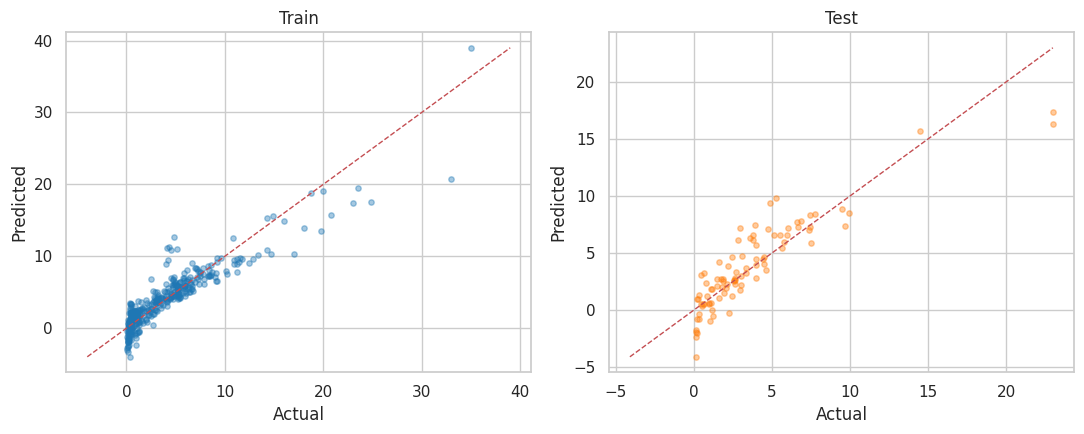

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, y_true, y_pred, title, c in [
    (axes[0], y_train, y_train_pred, "Train", "tab:blue"),
    (axes[1], y_test, y_test_pred, "Test", "tab:orange"),
]:
    ax.scatter(y_true, y_pred, alpha=0.4, s=15, color=c)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted"); ax.set_title(title)
plt.tight_layout()
plt.show()

# Task 2

**Scenario:**
You are provided with a dataset and your task is to determine whether applying linear regression is appropriate. Remember the fundamental assumptions of linear regression while making your decision.

**Dataset Description:**
The dataset contains numerical values representing various factors related to monthly electricity consumption in households. The features include the number of residents, average income, and the age of the house. The target variable is the monthly electricity consumption in kilowatt-hours.

**Task Instructions:**
**Review the Dataset:**
Familiarize yourself with the dataset, noting the features and the target variable.

**Assumption Consideration:**
Reflect on the key assumptions of linear regression: linearity, independence, homoscedasticity, normality of residuals, and absence of perfect multicollinearity.
Think about how these assumptions relate to the dataset. Consider whether the data might meet these assumptions or present challenges.

**Decision Making:**
Based solely on your understanding of the assumptions and by doing analysis, decide whether linear regression is suitable for this dataset. Provide a brief rationale for your decision.

**Justification:**
If you decided that linear regression is appropriate, outline why you believe the dataset meets the assumptions. If you decided against linear regression, briefly explain which assumptions you think the dataset violates.

In [21]:
#@title 📦 Kaggle Competition Loader { display-mode: "form" }
#@markdown ---
#@markdown ### How to use
#@markdown 1. In Colab, add **two** secrets via the 🔑 Secrets panel (left sidebar):
#@markdown    - `KAGGLE_USERNAME` → your Kaggle username
#@markdown    - `KAGGLE_KEY` → your Kaggle API key
#@markdown    Toggle "Notebook access" on for both.
#@markdown 2. Run this cell (code stays hidden — double-click the title to peek).
#@markdown 3. When prompted, paste the **full Kaggle competition URL**
#@markdown    (e.g. `https://www.kaggle.com/c/titanic`) — or just the slug.
#@markdown 4. After it finishes, your data is available as:
#@markdown    - `data['train.csv']`, `data['test.csv']`, etc. → pandas DataFrames
#@markdown    - `data['some_file.ext']` → file path (non-CSV files)
#@markdown    - `data_dir` → the local folder containing everything
#@markdown ---

import os
import re
import shutil
import kagglehub
import pandas as pd


def _authenticate_kaggle():
    """
    Pulls Kaggle credentials from Colab secrets and sets them as env vars,
    so kagglehub picks them up silently instead of falling back to
    kagglehub.login()'s interactive OAuth flow (which is what was hanging
    the automated run).
    """
    try:
        from google.colab import userdata
    except ImportError:
        # Not running in Colab — assume env vars/kaggle.json are already set up.
        return

    missing = []
    for env_name in ("KAGGLE_USERNAME", "KAGGLE_KEY"):
        if os.environ.get(env_name):
            continue  # already set
        try:
            value = userdata.get(env_name)
        except Exception:
            value = None
        if value:
            os.environ[env_name] = value
        else:
            missing.append(env_name)

    if missing:
        raise RuntimeError(
            "Missing Kaggle credential(s) in Colab secrets: "
            f"{', '.join(missing)}.\n"
            "Add them via the 🔑 Secrets panel in the left sidebar "
            "(toggle 'Notebook access' on for each), then re-run this cell."
        )


def _parse_kaggle_ref(text: str):
    """
    Determines whether the input points to a Kaggle *dataset* or
    *competition*, and extracts the identifier kagglehub needs.

    Returns:
        (kind, ref) where kind is 'dataset' or 'competition', and ref is
        either "owner/dataset-slug" (datasets) or "comp-slug" (competitions).
    """
    text = text.strip().rstrip('/')

    # Full dataset URL: kaggle.com/datasets/<owner>/<slug>
    match = re.search(r'kaggle\.com/datasets/([^/?#]+)/([^/?#]+)', text)
    if match:
        return 'dataset', f"{match.group(1)}/{match.group(2)}"

    # Full competition URL: kaggle.com/c/<slug> or kaggle.com/competitions/<slug>
    match = re.search(r'kaggle\.com/(?:c|competitions)/([^/?#]+)', text)
    if match:
        return 'competition', match.group(1)

    # Any other kaggle.com URL shape — can't reliably classify it
    if "kaggle.com" in text:
        return None, text.split('/')[-1]

    # Bare input, no domain: "owner/slug" implies a dataset handle;
    # a single token is treated as a competition slug.
    if '/' in text:
        return 'dataset', text
    return 'competition', text


def fetch_kaggle_competition(comp_url: str = None, copy_to_local: bool = True):
    """
    Downloads a Kaggle dataset or competition via kagglehub and loads all CSVs.

    Args:
        comp_url: Full Kaggle dataset/competition URL, or a slug
            ("comp-slug" for a competition, "owner/dataset-slug" for a
            dataset). If None, you'll be prompted.
        copy_to_local: If True, copies files out of the kagglehub cache into
            a local folder named after the slug.

    Returns:
        data: dict mapping filename -> DataFrame (for .csv) or filepath (other files)
        working_path: directory containing the dataset files
    """
    comp_input = comp_url or input("Paste Kaggle dataset/competition URL (or slug): ").strip()
    kind, comp_id = _parse_kaggle_ref(comp_input)

    if not comp_id:
        raise ValueError("Could not parse a dataset/competition identifier from that input.")
    if kind is None:
        raise ValueError(
            f"Couldn't tell whether '{comp_input}' is a dataset or a competition. "
            "Paste the full URL (kaggle.com/datasets/... or kaggle.com/c/...) "
            "or a bare slug (owner/dataset-slug, or comp-slug)."
        )

    print(f"\n[1/3] Authenticating & downloading {kind}: '{comp_id}'...")
    _authenticate_kaggle()
    try:
        if kind == 'dataset':
            cache_path = kagglehub.dataset_download(comp_id)
        else:
            cache_path = kagglehub.competition_download(comp_id)
    except Exception as e:
        if kind == 'competition':
            raise RuntimeError(
                f"Failed to download competition '{comp_id}'. If this is a 403, "
                f"make sure you've accepted the competition rules at "
                f"https://kaggle.com/competitions/{comp_id}/rules"
            ) from e
        raise RuntimeError(
            f"Failed to download dataset '{comp_id}'. Double-check the "
            "owner/slug is correct and the dataset is public (or you have access)."
        ) from e

    local_name = comp_id.replace('/', '_')
    target_dir = os.path.join(os.getcwd(), local_name)
    if copy_to_local:
        if os.path.exists(target_dir):
            shutil.rmtree(target_dir)
        shutil.copytree(cache_path, target_dir)
        working_path = target_dir
    else:
        working_path = cache_path

    print(f"[2/3] Files localized to: {working_path}")

    data = {}
    print("\n[3/3] Inspecting dataset contents:")
    for root, _, filenames in os.walk(working_path):
        for fname in sorted(filenames):
            fpath = os.path.join(root, fname)
            if fname.endswith('.csv'):
                data[fname] = pd.read_csv(fpath)
                print(f"  • {fname:30s} shape={data[fname].shape} -> data['{fname}']")
            else:
                data[fname] = fpath
                print(f"  • {fname:30s} (path saved) -> data['{fname}']")

    return data, working_path


# ==========================================
# RUN — paste your competition URL when asked
# ==========================================
data, data_dir = fetch_kaggle_competition()
print("\nAvailable keys:", list(data.keys()))

Paste Kaggle dataset/competition URL (or slug): https://www.kaggle.com/datasets/colabsss/power-customer-energy-behavior-data

[1/3] Authenticating & downloading dataset: 'colabsss/power-customer-energy-behavior-data'...
Using Colab cache for faster access to the 'power-customer-energy-behavior-data' dataset.
[2/3] Files localized to: /content/colabsss_power-customer-energy-behavior-data

[3/3] Inspecting dataset contents:
  • power_marketing_customer_electricity_dataset.csv shape=(15000, 38) -> data['power_marketing_customer_electricity_dataset.csv']

Available keys: ['power_marketing_customer_electricity_dataset.csv']


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

df = pd.read_csv("colabsss_power-customer-energy-behavior-data/power_marketing_customer_electricity_dataset.csv")
print(df.shape)
df.head()

(15000, 38)


,record_id,customer_id,timestamp,hour,day_of_week,month,is_weekend,season,customer_type,age,monthly_income_usd,household_size,home_area_sqft,appliance_count,has_solar_panel,has_ev,tariff_scheme,contract_type,temperature_c,humidity_percent,peak_hour,price_per_kwh,ac_usage_hours,heater_usage_hours,washing_machine_usage,lighting_usage_hours,cooking_usage_hours,entertainment_usage_hours,ev_charging_kwh,electricity_consumption_kwh,pricing_influence_score,weather_influence_score,appliance_influence_score,household_influence_score,previous_hour_consumption_kwh,previous_day_same_hour_consumption_kwh,rolling_24h_avg_consumption_kwh,consumption_behavior_category
0,667,10001,2025-01-28 18:00:00,18,1,1,0,Winter,Small_Commercial,66,3747,1,1355,23,0,1,Dynamic_Pricing,Green_Energy,13.36,64.44,1,0.2589,0.153,0.350,0,0.173,0.108,0.689,0.000,2.058,11.39,6.702,0.816,3.545,2.058,2.058,2.058,Moderate_Usage
1,778,10001,2025-02-02 09:00:00,9,6,2,1,Winter,Residential,38,5083,2,2535,9,1,0,Dynamic_Pricing,Green_Energy,16.31,65.40,1,0.2044,0.189,0.023,0,0.304,0.081,0.868,0.000,1.253,5.94,4.538,0.590,3.955,2.058,1.656,1.656,Low_Usage
2,1011,10001,2025-02-12 02:00:00,2,2,2,0,Winter,Residential,26,4405,7,1051,12,0,1,Peak_Valley,Green_Energy,7.71,80.43,0,0.1106,0.192,0.909,0,0.951,0.136,0.211,1.225,3.607,3.44,11.739,2.738,4.461,1.253,2.306,2.306,Peak_Intensive_Usage
3,1170,10001,2025-02-18 17:00:00,17,1,2,0,Winter,Residential,59,6962,3,1122,6,0,0,Time_of_Use,Premium_Service,16.17,73.78,0,0.1202,0.058,0.087,0,0.000,0.200,0.173,0.000,0.662,2.48,5.061,0.280,2.652,3.607,1.895,1.895,Low_Usage
4,2037,10001,2025-03-26 20:00:00,20,2,3,0,Spring,Residential,38,3972,4,1892,14,0,0,Flat,Green_Energy,18.11,76.89,1,0.1355,0.043,0.038,0,0.672,0.663,0.622,0.000,1.496,0.95,3.762,0.701,4.412,0.662,1.815,1.815,Low_Usage


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 38 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   record_id                               15000 non-null  int64  
 1   customer_id                             15000 non-null  int64  
 2   timestamp                               15000 non-null  object 
 3   hour                                    15000 non-null  int64  
 4   day_of_week                             15000 non-null  int64  
 5   month                                   15000 non-null  int64  
 6   is_weekend                              15000 non-null  int64  
 7   season                                  15000 non-null  object 
 8   customer_type                           15000 non-null  object 
 9   age                                     15000 non-null  int64  
 10  monthly_income_usd                      15000 non-null  in

## Checking for target leakage among candidate features

Before picking features, check how strongly the lagged/rolling consumption columns and
the behavior-category column relate to the target itself.

In [25]:
target = "electricity_consumption_kwh"

suspect_cols = [
    "previous_hour_consumption_kwh",
    "previous_day_same_hour_consumption_kwh",
    "rolling_24h_avg_consumption_kwh"
]

print(df[suspect_cols + [target]].corr()[target])
print()
print(df.groupby("consumption_behavior_category")[target].describe())

previous_hour_consumption_kwh             0.099062
previous_day_same_hour_consumption_kwh    0.395410
rolling_24h_avg_consumption_kwh           0.420764
electricity_consumption_kwh               1.000000
Name: electricity_consumption_kwh, dtype: float64

                                count      mean       std    min    25%  \
consumption_behavior_category                                             
High_Usage                     3444.0  2.449894  0.158795  2.206  2.313   
Low_Usage                      4501.0  1.262114  0.220482  0.280  1.124   
Moderate_Usage                 5257.0  1.892601  0.181793  1.576  1.734   
Peak_Intensive_Usage           1798.0  3.322467  0.707650  2.774  2.908   

                                 50%     75%    max  
consumption_behavior_category                        
High_Usage                     2.435  2.5800  2.773  
Low_Usage                      1.298  1.4410  1.575  
Moderate_Usage                 1.896  2.0500  2.205  
Peak_Intensive_Usage    

## Checking whether the "influence_score" columns are engineered from raw features

If these scores are just linear/derived combinations of other columns, they'll create
artificial multicollinearity and shouldn't be included alongside the raw features.

In [26]:
influence_cols = [
    "pricing_influence_score", "weather_influence_score",
    "appliance_influence_score", "household_influence_score"
]

raw_candidates = [
    "price_per_kwh", "tariff_scheme",
    "temperature_c", "humidity_percent",
    "appliance_count", "ac_usage_hours", "heater_usage_hours",
    "household_size", "home_area_sqft", "monthly_income_usd", "age"
]

print(df[influence_cols].describe())
print()
print(df[influence_cols + ["price_per_kwh", "temperature_c", "humidity_percent",
   50%                     0.921000                   4.203000
75%                     1.421000                   4.986000
max                     8.386000                   7.248000

                           pricing_influence_score  weather_influence_score  \\
pricing_influence_score                   $0                         "appliance_count", "household_size"]].corr())

       pricing_influence_score  weather_influence_score  \
count             15000.000000             15000.000000   
mean                  2.485628                 6.330095   
std                   2.331150                 4.066638   
min                   0.000000                 0.002000   
25%                   0.550000                 3.161750   
50%                   1.810000                 5.414000   
75%                   3.620000                 9.002000   
max                  13.110000                19.528000   

       appliance_influence_score  household_influence_score  
count               15000.000000               15000.000000  
mean                    1.026010                   4.204896  
std                     0.593636                   1.094206  
min                     0.079000                   1.216000  
25%                     0.570000                   3.430000  
50%                     0.921000                   4.203000  
75%                     1.421000  

In [27]:
influence_cols = [
    "pricing_influence_score", "weather_influence_score",
    "appliance_influence_score", "household_influence_score"
]
print(df[influence_cols + [target]].corr()[target])

pricing_influence_score        0.068946
weather_influence_score        0.495482
appliance_influence_score      0.839895
household_influence_score      0.193471
electricity_consumption_kwh    1.000000
Name: electricity_consumption_kwh, dtype: float64


## Finalizing the Feature Set

Dropping identifiers, the leaked behavior-category label, the derived influence scores,
and lagged/rolling consumption columns. One-hot encoding the remaining categoricals.

In [28]:
drop_cols = [
    "record_id", "customer_id", "timestamp",
    "consumption_behavior_category",
    "pricing_influence_score", "weather_influence_score",
    "appliance_influence_score", "household_influence_score",
    "previous_hour_consumption_kwh",
    "previous_day_same_hour_consumption_kwh",
    "rolling_24h_avg_consumption_kwh",
]

categorical_cols = ["season", "customer_type", "tariff_scheme", "contract_type"]

model_df = df.drop(columns=drop_cols)
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

feature_cols = [c for c in model_df.columns if c != target]
print(f"{len(feature_cols)} features:")
print(feature_cols)
model_df.head()

32 features:
['hour', 'day_of_week', 'month', 'is_weekend', 'age', 'monthly_income_usd', 'household_size', 'home_area_sqft', 'appliance_count', 'has_solar_panel', 'has_ev', 'temperature_c', 'humidity_percent', 'peak_hour', 'price_per_kwh', 'ac_usage_hours', 'heater_usage_hours', 'washing_machine_usage', 'lighting_usage_hours', 'cooking_usage_hours', 'entertainment_usage_hours', 'ev_charging_kwh', 'season_Spring', 'season_Summer', 'season_Winter', 'customer_type_Residential', 'customer_type_Small_Commercial', 'tariff_scheme_Flat', 'tariff_scheme_Peak_Valley', 'tariff_scheme_Time_of_Use', 'contract_type_Green_Energy', 'contract_type_Premium_Service']


,hour,day_of_week,month,is_weekend,age,monthly_income_usd,household_size,home_area_sqft,appliance_count,has_solar_panel,has_ev,temperature_c,humidity_percent,peak_hour,price_per_kwh,ac_usage_hours,heater_usage_hours,washing_machine_usage,lighting_usage_hours,cooking_usage_hours,entertainment_usage_hours,ev_charging_kwh,electricity_consumption_kwh,season_Spring,season_Summer,season_Winter,customer_type_Residential,customer_type_Small_Commercial,tariff_scheme_Flat,tariff_scheme_Peak_Valley,tariff_scheme_Time_of_Use,contract_type_Green_Energy,contract_type_Premium_Service
0,18,1,1,0,66,3747,1,1355,23,0,1,13.36,64.44,1,0.2589,0.153,0.350,0,0.173,0.108,0.689,0.000,2.058,False,False,True,False,True,False,False,False,True,False
1,9,6,2,1,38,5083,2,2535,9,1,0,16.31,65.40,1,0.2044,0.189,0.023,0,0.304,0.081,0.868,0.000,1.253,False,False,True,True,False,False,False,False,True,False
2,2,2,2,0,26,4405,7,1051,12,0,1,7.71,80.43,0,0.1106,0.192,0.909,0,0.951,0.136,0.211,1.225,3.607,False,False,True,True,False,False,True,False,True,False
3,17,1,2,0,59,6962,3,1122,6,0,0,16.17,73.78,0,0.1202,0.058,0.087,0,0.000,0.200,0.173,0.000,0.662,False,False,True,True,False,False,False,True,False,True
4,20,2,3,0,38,3972,4,1892,14,0,0,18.11,76.89,1,0.1355,0.043,0.038,0,0.672,0.663,0.622,0.000,1.496,True,False,False,True,False,True,False,False,True,False


## Assumption 1 — Linearity

Check the linear correlation of each feature with the target, then visualize the
strongest relationships with scatter plots + a LOWESS smoother to see whether the
relationship actually looks straight or curved.

In [29]:
corr_with_target = model_df.corr(numeric_only=True)[target].drop(target).sort_values(key=abs, ascending=False)
corr_with_target.to_frame("correlation_with_target")

,correlation_with_target
ev_charging_kwh,0.513111
customer_type_Residential,-0.370965
ac_usage_hours,0.342009
heater_usage_hours,0.321285
season_Summer,0.254289
has_ev,0.245539
peak_hour,0.234090
entertainment_usage_hours,0.229898
season_Spring,-0.211775
customer_type_Small_Commercial,0.210425


### Visualizing the strongest linear relationships

Scatter plots with a LOWESS smoother for the top continuous predictors by |correlation|.
A straight smoothed line supports linearity; a curved one suggests linearity is violated
even where correlation isn't zero.

/usr/local/lib/python3.13/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:237: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(


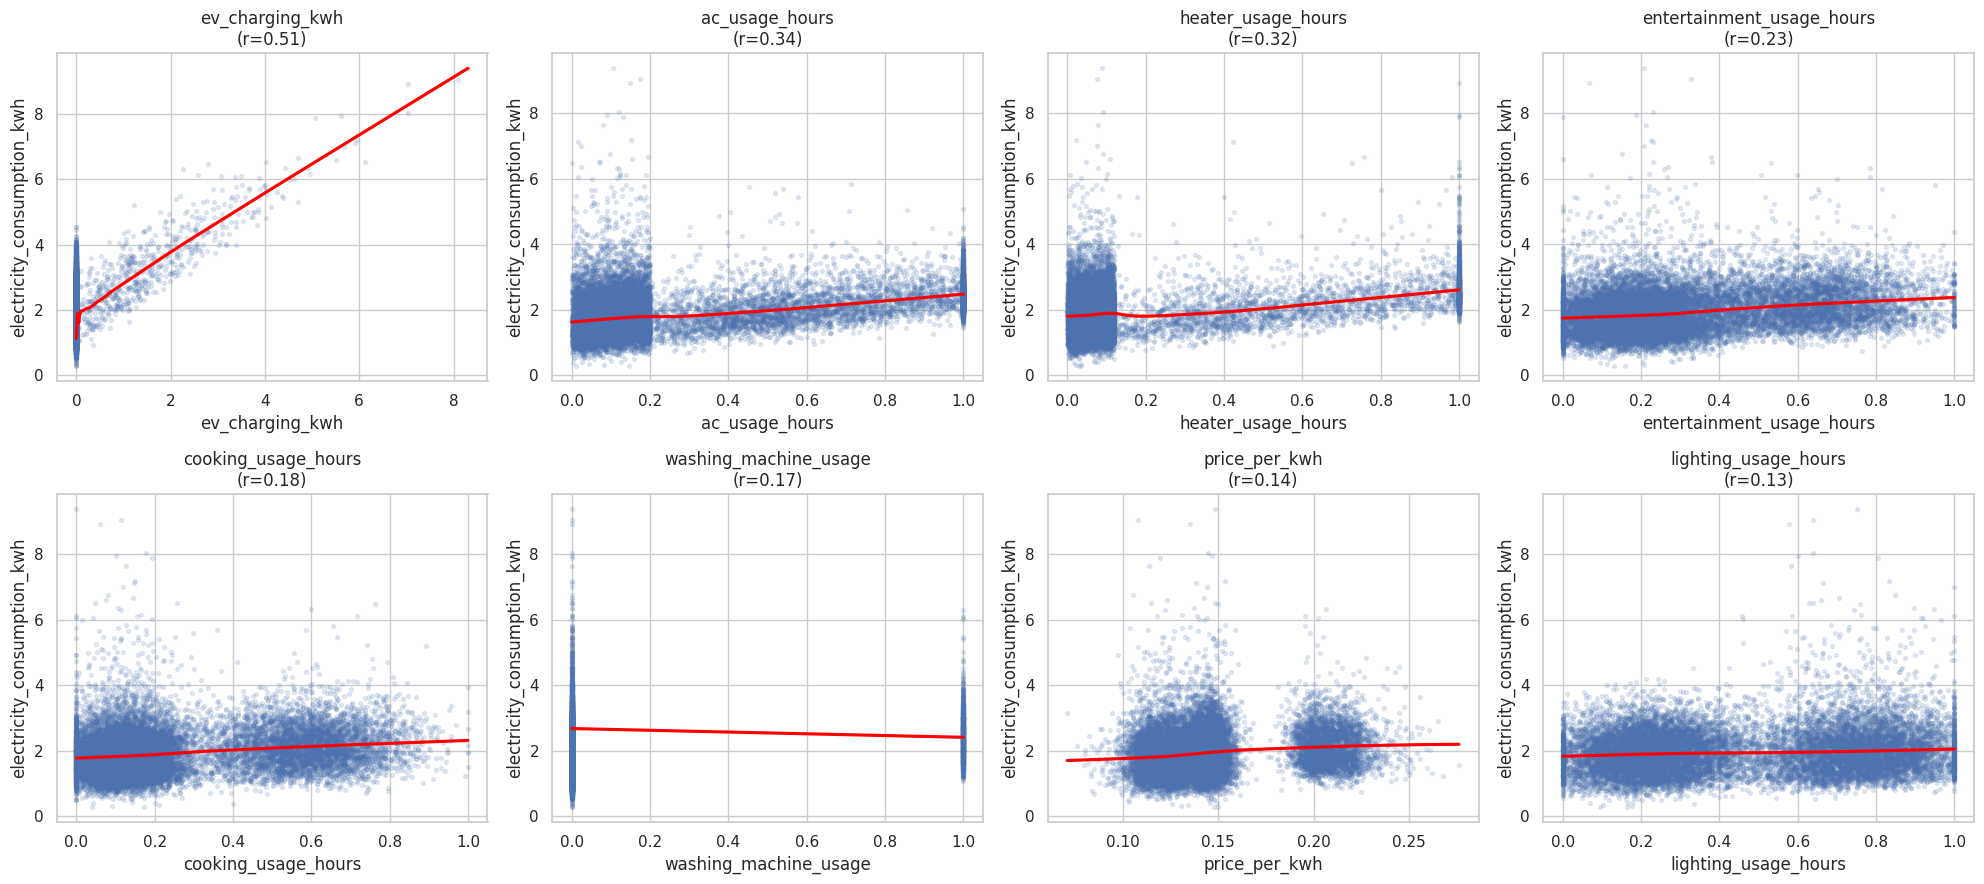

In [30]:
top_continuous = [
    "ev_charging_kwh", "ac_usage_hours", "heater_usage_hours",
    "entertainment_usage_hours", "cooking_usage_hours",
    "washing_machine_usage", "price_per_kwh", "lighting_usage_hours"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()

for i, col in enumerate(top_continuous):
    sns.regplot(x=model_df[col], y=model_df[target], ax=axes[i],
                lowess=True, scatter_kws={"alpha": 0.15, "s": 8},
                line_kws={"color": "red"})
    axes[i].set_title(f"{col}\n(r={corr_with_target[col]:.2f})")

plt.tight_layout()
plt.show()

## Fit Baseline Linear Regression Model (scikit-learn)

Fit an ordinary least squares model using scikit-learn to get fitted values and
residuals, which the remaining assumption tests (independence, homoscedasticity,
normality) depend on.

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = model_df[feature_cols].astype(float)
y = model_df[target]

lr_model = LinearRegression()
lr_model.fit(X, y)

fitted = lr_model.predict(X)
residuals = y - fitted

r2 = r2_score(y, fitted)
mae = mean_absolute_error(y, fitted)
rmse = mean_squared_error(y, fitted) ** 0.5

print(f"R-squared: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R-squared: 0.9535
MAE: 0.1225
RMSE: 0.1548


In [32]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

coef_df

,feature,coefficient
14,price_per_kwh,-1.487021
15,ac_usage_hours,1.198124
25,customer_type_Residential,-1.054142
16,heater_usage_hours,1.040209
21,ev_charging_kwh,0.948910
26,customer_type_Small_Commercial,-0.580701
17,washing_machine_usage,0.455989
19,cooking_usage_hours,0.373434
13,peak_hour,0.321415
18,lighting_usage_hours,0.307978


## Assumption 2 — Independence of Residuals

Check two things:
1. Durbin-Watson statistic on residuals in their current row order (~2.0 = no
   autocorrelation).
2. Whether residuals are correlated within the same customer_id — since multiple rows
   per household are repeated measurements, not independent draws.

   $DW = Σ(eᵢ − eᵢ₋₁)² / Σeᵢ²$

In [33]:
import numpy as np

resid_arr = residuals.values
dw_stat = np.sum(np.diff(resid_arr)**2) / np.sum(resid_arr**2)
print(f"Durbin-Watson statistic: {dw_stat:.3f}")

Durbin-Watson statistic: 2.018


## Assumption 3 — Homoscedasticity

Plot residuals vs fitted values. We want a random, constant-width band around zero —
a funnel/cone shape would mean variance grows with the fitted value (violation).

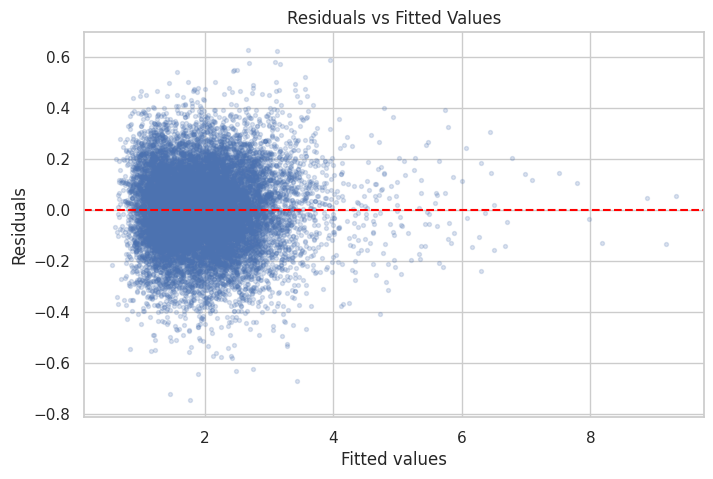

In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals, alpha=0.2, s=8)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

## Assumption 4 — Normality of Residuals

Histogram + Q-Q plot of residuals, plus a Shapiro-Wilk test (scipy) to check for
approximate normality. Shapiro-Wilk's null hypothesis is that the data is normal —
a small p-value means we reject that (residuals deviate from normal).

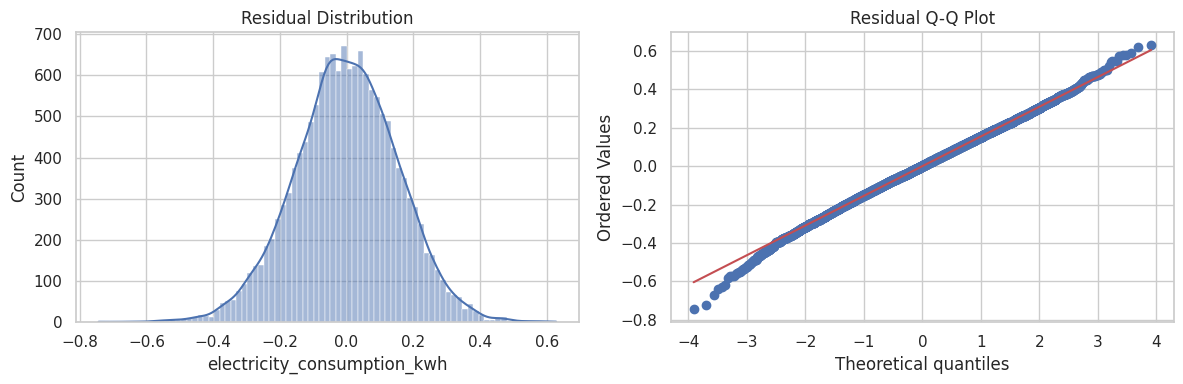

Shapiro-Wilk p-value (n=5000): 0.08197


In [35]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title("Residual Distribution")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Residual Q-Q Plot")

plt.tight_layout()
plt.show()

# Shapiro-Wilk is sensitive at large n; subsample for a stable read
sample = residuals if len(residuals) <= 5000 else residuals.sample(5000, random_state=42)
sw_stat, sw_pvalue = stats.shapiro(sample)
print(f"Shapiro-Wilk p-value (n={len(sample)}): {sw_pvalue:.4g}")

In [36]:
sample = residuals if len(residuals) <= 5000 else residuals.sample(5000, random_state=42)
sw_stat, sw_pvalue = stats.shapiro(sample)
print(f"Shapiro-Wilk p-value (n={len(sample)}): {sw_pvalue:.4g}")

Shapiro-Wilk p-value (n=5000): 0.08197


## Assumption 5 — Absence of (Near-)Perfect Multicollinearity

Check the correlation matrix among features, then compute Variance Inflation Factor
(VIF) for each — using sklearn instead of statsmodels. VIF = 1 / (1 - R²), where R²
comes from regressing that feature on all the other features.

Rule of thumb: VIF < 5 low concern, 5–10 moderate, > 10 severe multicollinearity.

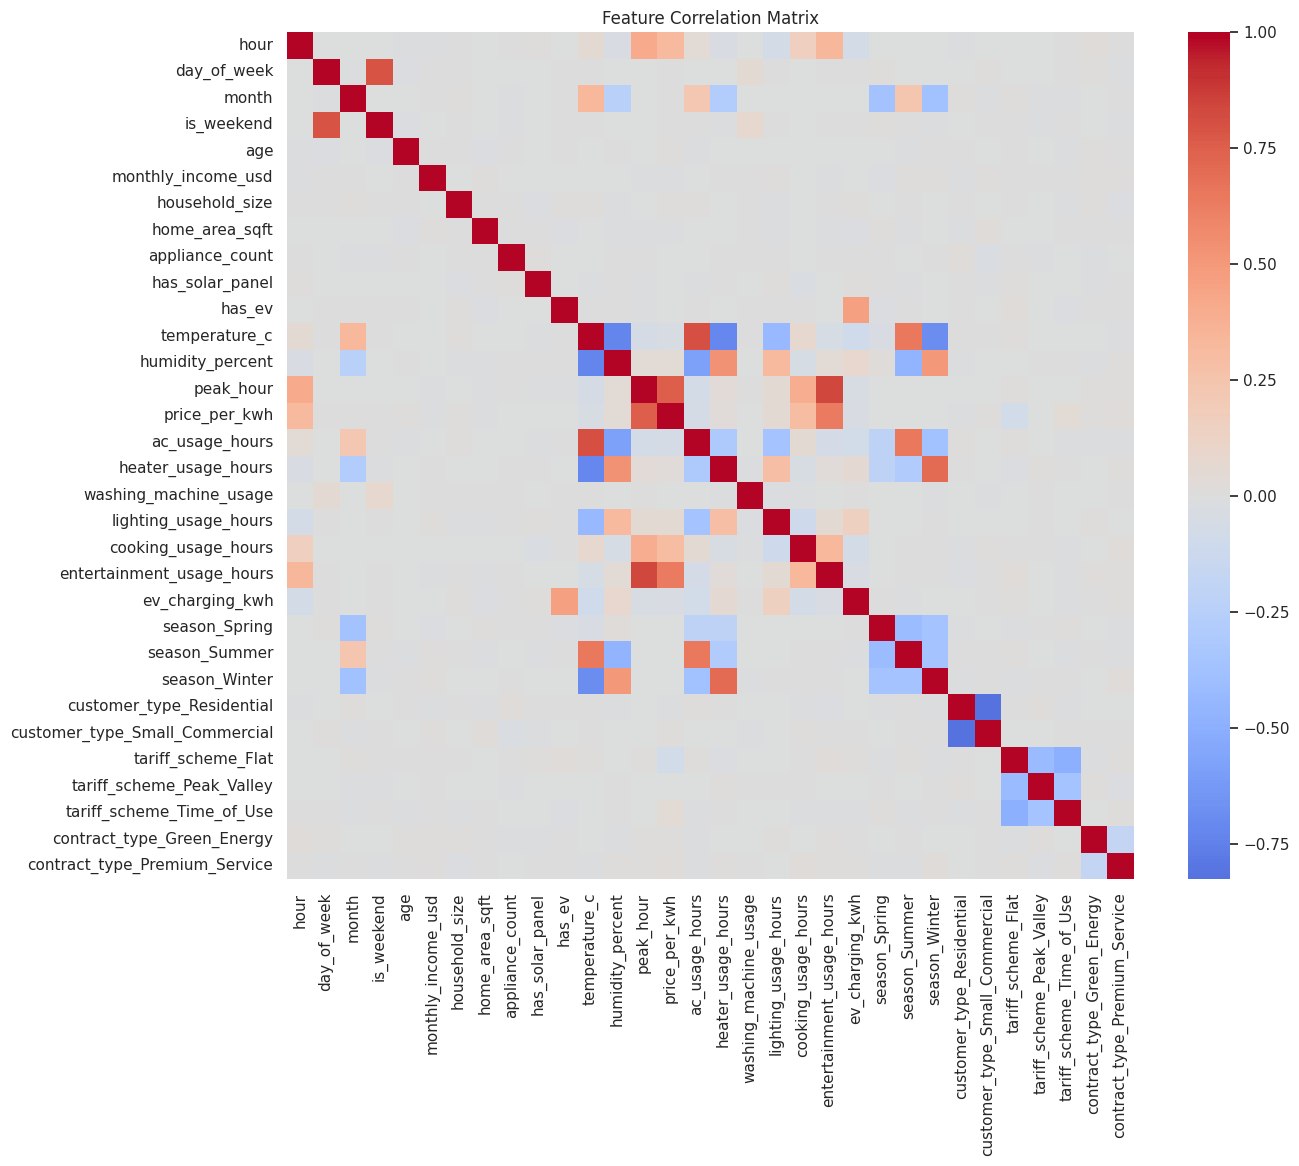

In [37]:
plt.figure(figsize=(14, 11))
sns.heatmap(X.corr(), cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [38]:
def compute_vif(X):
    vifs = []
    for i, col in enumerate(X.columns):
        X_others = X.drop(columns=[col])
        y_col = X[col]
        r2 = LinearRegression().fit(X_others, y_col).score(X_others, y_col)
        vif = 1 / (1 - r2) if r2 < 1 else np.inf
        vifs.append(vif)
    return pd.DataFrame({"feature": X.columns, "VIF": vifs}).sort_values("VIF", ascending=False)

vif_df = compute_vif(X)
vif_df

,feature,VIF
11,temperature_c,16.711751
24,season_Winter,5.640559
13,peak_hour,5.191234
15,ac_usage_hours,5.166766
16,heater_usage_hours,4.048712
23,season_Summer,3.685598
20,entertainment_usage_hours,3.390971
22,season_Spring,3.376310
26,customer_type_Small_Commercial,3.168482
25,customer_type_Residential,3.166397


## Final Decision: Is Linear Regression Appropriate?

| Assumption | Result | Evidence |
|---|---|---|
| **1. Linearity** | ⚠️ Partially violated | Most features weakly linear (r < 0.35); `ev_charging_kwh` shows a distinct kink (two regimes, not one line); several usage-hour features show flat/non-monotonic LOWESS curves |
| **2. Independence** | ✅ Holds | Durbin-Watson = 2.018, essentially no autocorrelation |
| **3. Homoscedasticity** | ⚠️ Mostly holds | Fairly constant spread in the dense region (fitted 1–3), but variance thins/behaves oddly in the sparse high-fitted-value tail (EV-charging households) |
| **4. Normality of residuals** | ⚠️ Borderline | Shapiro-Wilk p = 0.082 (technically not rejected), but Q-Q plot shows visible heavy-tail bowing |
| **5. No severe multicollinearity** | ⚠️ One violation | `temperature_c` has VIF = 16.7 (severe); a few features (peak_hour, ac_usage_hours, season_Winter) are moderate (5–6) |

**Verdict:** Linear regression is **usable but not ideal as-is**. It achieves a high R² (0.95),
but that mostly reflects a handful of well-behaved, dominant features (like `ac_usage_hours`,
`heater_usage_hours`, `price_per_kwh`) doing the real work, while several assumptions are
only partially satisfied rather than cleanly met.

**Recommended fixes before trusting this model:**
- Drop `temperature_c` (or drop the appliance-usage-hour proxies instead) to resolve the severe multicollinearity
- Consider modeling EV-charging households separately, or adding an interaction/segment flag for `has_ev`, since that relationship is visibly non-linear/two-regime
- The heavy Q-Q tails and thin high-fitted-value variance both trace back to the same EV-charging subgroup — worth investigating as an outlier/subpopulation issue rather than a global linearity failure